# In-situ SM skill from raw_timeseries (MATLAB cache)

This notebook mirrors `SMskill_vs_INSITU_single_CYG_expt.m` **after** the raw time series are cached.
It reads the `*_raw_timeseries.mat` files and computes the same statistics (R, anomR, Bias, RMSE, ubRMSE
+ CI) using the Python ported functions.

Notes:
- This assumes the MAT file contains `LDAS_sm_org`, `INSITU_sm`, and `date_time_vec` (MATLAB struct array).
- If your MAT file is v7.3 (HDF5), scipy may fail; see the loader cell for fallbacks.


In [1]:
from pathlib import Path
import sys
import numpy as np
import scipy.io as sio
import xarray as xr

# ---- paths ----
RAW_MAT_FILES = [
    Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat"),
    Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_DAv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat"),
]

OUT_DIR = Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2")
INSITU_TAG = "SCAN"
FILE_TAG = "ldas_tile_daily_out"
ADD_ANOMR = True

# ---- import stats helpers from existing script ----
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))

from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore


In [2]:
# ---- MAT loader helpers ----


def load_mat_file(path: Path):
    # Load MATLAB MAT file. Tries scipy (v5/v7), falls back to h5py for v7.3.
    try:
        return sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    except NotImplementedError as e:
        # Likely v7.3
        try:
            import h5py
        except Exception as e2:
            raise RuntimeError(
                f"MAT file appears to be v7.3 (HDF5) but h5py is not available: {e2}"
            ) from e
        with h5py.File(path, "r") as f:
            # Shallow read: expose top-level keys for manual mapping
            return {k: f[k] for k in f.keys()}



def mat_struct_to_array(ms, field):
    # Extract a field from a MATLAB struct array loaded with scipy (struct_as_record=False).
    if isinstance(ms, np.ndarray):
        flat = ms.ravel()
        return np.array([getattr(x, field) for x in flat])
    return np.array([getattr(ms, field)])



def summarize_mat(mat):
    keys = [k for k in mat.keys() if not k.startswith("__")]
    print("Keys:", keys)
    for k in keys:
        v = mat[k]
        if hasattr(v, "shape"):
            print(f"  {k}: shape={v.shape}, dtype={getattr(v, 'dtype', None)}")
        else:
            print(f"  {k}: type={type(v)}")


In [3]:
# ---- core computation ----


def compute_stats_from_raw(mat, file_tag: str, insitu_tag: str, add_anomR: bool = True):
    # Required arrays
    if "LDAS_sm_org" not in mat or "INSITU_sm" not in mat or "date_time_vec" not in mat:
        raise KeyError("MAT file must contain LDAS_sm_org, INSITU_sm, and date_time_vec")

    ldas_sm_org = mat["LDAS_sm_org"]
    insitu_sm = mat["INSITU_sm"]
    dt_vec = mat["date_time_vec"]

    # Normalize dimensions: LDAS_sm_org expected (time, depth, site[, exp])
    if ldas_sm_org.ndim == 4:
        ldas_sm_org = ldas_sm_org[:, :, :, 0]
    if ldas_sm_org.ndim != 3:
        raise ValueError(f"Unexpected LDAS_sm_org shape {ldas_sm_org.shape}")

    # INSITU_sm expected (time, depth, site)
    if insitu_sm.ndim != 3:
        raise ValueError(f"Unexpected INSITU_sm shape {insitu_sm.shape}")

    # Build doy vector from date_time_vec.dofyr if present
    if hasattr(dt_vec, "dtype") or isinstance(dt_vec, np.ndarray):
        try:
            doy_vec = mat_struct_to_array(dt_vec, "dofyr").astype(int).ravel()
        except Exception:
            # fallback: try year/month/day and compute doy
            year = mat_struct_to_array(dt_vec, "year").astype(int).ravel()
            month = mat_struct_to_array(dt_vec, "month").astype(int).ravel()
            day = mat_struct_to_array(dt_vec, "day").astype(int).ravel()
            import datetime as _dt
            doy_vec = np.array([_dt.date(int(y), int(m), int(d)).timetuple().tm_yday for y, m, d in zip(year, month, day)])
    else:
        raise ValueError("date_time_vec is not a scipy MATLAB struct array; inspect manually")

    # Nmin like MATLAB
    Nmin = 200 if "daily" in file_tag else 480
    Nmin_day = 60

    # Cross-mask model/obs
    ldas_sm = np.copy(ldas_sm_org[:, :2, :])
    ldas_sm[ldas_sm == 0] = np.nan
    ldas_sm[np.isnan(insitu_sm)] = np.nan
    insitu_sm = np.where(np.isnan(ldas_sm), np.nan, insitu_sm)

    n_time, n_depth, n_site = ldas_sm.shape

    # Allocate
    stats_R = np.full((n_site, n_depth), np.nan)
    stats_RLO = np.full((n_site, n_depth), np.nan)
    stats_RUP = np.full((n_site, n_depth), np.nan)
    stats_bias = np.full((n_site, n_depth), np.nan)
    stats_biasCI = np.full((n_site, n_depth), np.nan)
    stats_rmse = np.full((n_site, n_depth), np.nan)
    stats_rmseCI = np.full((n_site, n_depth), np.nan)
    stats_ubrmse = np.full((n_site, n_depth), np.nan)
    stats_ubrmseCI = np.full((n_site, n_depth), np.nan)
    stats_anomR = np.full((n_site, n_depth), np.nan) if add_anomR else None
    stats_anomRLO = np.full((n_site, n_depth), np.nan) if add_anomR else None
    stats_anomRUP = np.full((n_site, n_depth), np.nan) if add_anomR else None

    for i_site in range(n_site):
        for j_depth in range(n_depth):
            tmp = np.column_stack([insitu_sm[:, j_depth, i_site], ldas_sm[:, j_depth, i_site]])
            s = get_validation_stats(tmp, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
            stats_R[i_site, j_depth] = s["R"]
            stats_RLO[i_site, j_depth] = s["RLO"]
            stats_RUP[i_site, j_depth] = s["RUP"]
            stats_bias[i_site, j_depth] = s["bias"]
            stats_biasCI[i_site, j_depth] = s["CI_bias"]
            rmse = np.sqrt(s["MSE"]) if not np.isnan(s["MSE"]) else np.nan
            stats_rmse[i_site, j_depth] = rmse
            stats_rmseCI[i_site, j_depth] = np.sqrt(max(s["CI_MSE"] + s["MSE"], 0)) - rmse if not np.isnan(s["CI_MSE"]) else np.nan
            ubmse = s["ubMSE"]
            stats_ubrmse[i_site, j_depth] = np.sqrt(ubmse) if not np.isnan(ubmse) else np.nan
            if not np.isnan(s["ubMSELO"]):
                stats_ubrmseCI[i_site, j_depth] = np.sqrt(max(ubmse + s["ubMSEUP"], 0)) - stats_ubrmse[i_site, j_depth]
            if add_anomR:
                obs_anom = compute_anom(tmp[:, 0], doy_vec, Nmin_day=Nmin_day)
                mod_anom = compute_anom(tmp[:, 1], doy_vec, Nmin_day=Nmin_day)
                tmp_anom = np.column_stack([obs_anom, mod_anom])
                sa = get_validation_stats(tmp_anom, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
                stats_anomR[i_site, j_depth] = sa["R"]
                stats_anomRLO[i_site, j_depth] = sa["RLO"]
                stats_anomRUP[i_site, j_depth] = sa["RUP"]

    return {
        "R": stats_R,
        "RLO": stats_RLO,
        "RUP": stats_RUP,
        "Bias": stats_bias,
        "BiasCI": stats_biasCI,
        "RMSE": stats_rmse,
        "RMSECI": stats_rmseCI,
        "ubRMSE": stats_ubrmse,
        "ubRMSECI": stats_ubrmseCI,
        "anomR": stats_anomR,
        "anomRLO": stats_anomRLO,
        "anomRUP": stats_anomRUP,
        "Nmin": Nmin,
    }


In [4]:
# ---- run for each raw_timeseries file ----

OUT_DIR.mkdir(parents=True, exist_ok=True)

results = {}
meta = {}

for raw_path in RAW_MAT_FILES:
    print(f"Loading {raw_path} ...")
    mat = load_mat_file(raw_path)
    summarize_mat(mat)

    stats = compute_stats_from_raw(mat, FILE_TAG, INSITU_TAG, add_anomR=ADD_ANOMR)

    # Optional metadata if present
    ids = None
    lat = None
    lon = None
    if "INSITU_id" in mat:
        ids = [str(x) for x in np.ravel(mat["INSITU_id"])]
    if "INSITU_lat" in mat:
        lat = np.ravel(mat["INSITU_lat"]).astype(float)
    if "INSITU_lon" in mat:
        lon = np.ravel(mat["INSITU_lon"]).astype(float)

    exp_key = raw_path.name.replace("_raw_timeseries.mat", "")
    results[exp_key] = dict(stats=stats, ids=ids, lat=lat, lon=lon)
    if not meta and ids is not None and lat is not None and lon is not None:
        meta = dict(ids=ids, lat=lat, lon=lon)

    n_site, n_depth = stats["R"].shape
    ds = xr.Dataset(
        data_vars={
            "R": (("site", "depth"), stats["R"]),
            "RLO": (("site", "depth"), stats["RLO"]),
            "RUP": (("site", "depth"), stats["RUP"]),
            "Bias": (("site", "depth"), stats["Bias"]),
            "BiasCI": (("site", "depth"), stats["BiasCI"]),
            "RMSE": (("site", "depth"), stats["RMSE"]),
            "RMSECI": (("site", "depth"), stats["RMSECI"]),
            "ubRMSE": (("site", "depth"), stats["ubRMSE"]),
            "ubRMSECI": (("site", "depth"), stats["ubRMSECI"]),
        },
        coords=dict(
            site=np.arange(n_site),
            depth=np.arange(n_depth),
        ),
        attrs=dict(
            insitu_tag=INSITU_TAG,
            file_tag=FILE_TAG,
            Nmin=int(stats["Nmin"]),
            add_anomR=int(ADD_ANOMR),
            source_raw=str(raw_path),
        ),
    )

    if ADD_ANOMR:
        ds["anomR"] = (("site", "depth"), stats["anomR"])
        ds["anomRLO"] = (("site", "depth"), stats["anomRLO"])
        ds["anomRUP"] = (("site", "depth"), stats["anomRUP"])

    if ids is not None:
        ds = ds.assign_coords(site_id=("site", ids))
    if lat is not None:
        ds = ds.assign_coords(site_lat=("site", lat))
    if lon is not None:
        ds = ds.assign_coords(site_lon=("site", lon))

    base = raw_path.name.replace("_raw_timeseries.mat", "_stats")
    out_nc = OUT_DIR / f"{base}.nc"
    out_npz = OUT_DIR / f"{base}.npz"

    ds.to_netcdf(out_nc)
    np.savez_compressed(out_npz, **{k: v for k, v in stats.items() if k not in ["Nmin"]})

    print(f"Wrote {out_nc}")
    print(f"Wrote {out_npz}")


Loading /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat ...
Keys: ['INSITU_id', 'INSITU_id_string', 'INSITU_lat', 'INSITU_lon', 'INSITU_path', 'INSITU_sm', 'INSITU_st', 'INSITU_tag', 'LDAS_prcp_org', 'LDAS_sm_org', 'LDAS_st_org', 'Nmin', 'add_anomR', 'data_ext', 'date_time', 'date_time_string', 'date_time_vec', 'date_time_vec1', 'distance', 'distance_min', 'domain', 'dtstep', 'end_time', 'exp_path', 'exp_run', 'exp_run_name', 'file_ext', 'file_tag', 'fname', 'fname_tilecoord', 'fname_tmp', 'fout_name', 'fout_path', 'i', 'ind_hour', 'ind_tile', 'ind_tmp', 'j', 'k', 'kkk', 'max_distance', 'out_collection', 'ref_T', 'ref_YMD', 'rzmc_tag', 'start_time', 't_ind', 'tavg_tag_INSITU', 'tc', 'this_lat', 'this_lon', 'tile_coord', 'tmpstr', 'w_mat_tmp', 'w_mat_tmp3d', 'w_tmp']
  INSITU_id: shape=(146,), dtype=object
  INSITU_id_string: type=<class 'str'>
  INSITU_lat: shape=(146,), dtype=float64
  INSITU_lon: shape=(

In [5]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False


In [6]:
# ---- aggregate stats for plotting ----

if not results:
    raise RuntimeError("No results found. Run the previous cell first.")

exp_keys = list(results.keys())
exp_labels = [k.replace("LS_", "").replace("_M36", "") for k in exp_keys]

R = np.stack([results[k]["stats"]["R"] for k in exp_keys], axis=2)
RLO = np.stack([results[k]["stats"]["RLO"] for k in exp_keys], axis=2)
RUP = np.stack([results[k]["stats"]["RUP"] for k in exp_keys], axis=2)
ubRMSE = np.stack([results[k]["stats"]["ubRMSE"] for k in exp_keys], axis=2)

anomR = None
anomRLO = None
anomRUP = None
if ADD_ANOMR:
    anomR = np.stack([results[k]["stats"]["anomR"] for k in exp_keys], axis=2)
    anomRLO = np.stack([results[k]["stats"]["anomRLO"] for k in exp_keys], axis=2)
    anomRUP = np.stack([results[k]["stats"]["anomRUP"] for k in exp_keys], axis=2)

num_sites_r = np.sum(~np.isnan(R), axis=0)
R_mean = np.nanmean(R, axis=0)
R_CI = np.array([
    -np.nanmean(RLO, axis=0) / np.sqrt(num_sites_r),
    np.nanmean(RUP, axis=0) / np.sqrt(num_sites_r),
])

num_sites_ubrmse = np.sum(~np.isnan(ubRMSE), axis=0)
ubRMSE_mean = np.nanmean(ubRMSE, axis=0)

# If ubRMSECI is present (single-sided), use it symmetrically
try:
    ub_ci = np.stack([results[k]["stats"]["ubRMSECI"] for k in exp_keys], axis=2)
    ub_ci_mean = np.abs(np.nanmean(ub_ci, axis=0) / np.sqrt(num_sites_ubrmse))
    ubRMSE_CI = np.array([ub_ci_mean, ub_ci_mean])
except Exception:
    ubRMSE_CI = np.zeros((2,) + ubRMSE_mean.shape)

if anomR is not None:
    num_sites_anomr = np.sum(~np.isnan(anomR), axis=0)
    anomR_mean = np.nanmean(anomR, axis=0)
    anomR_CI = np.array([
        -np.nanmean(anomRLO, axis=0) / np.sqrt(num_sites_anomr),
        np.nanmean(anomRUP, axis=0) / np.sqrt(num_sites_anomr),
    ])


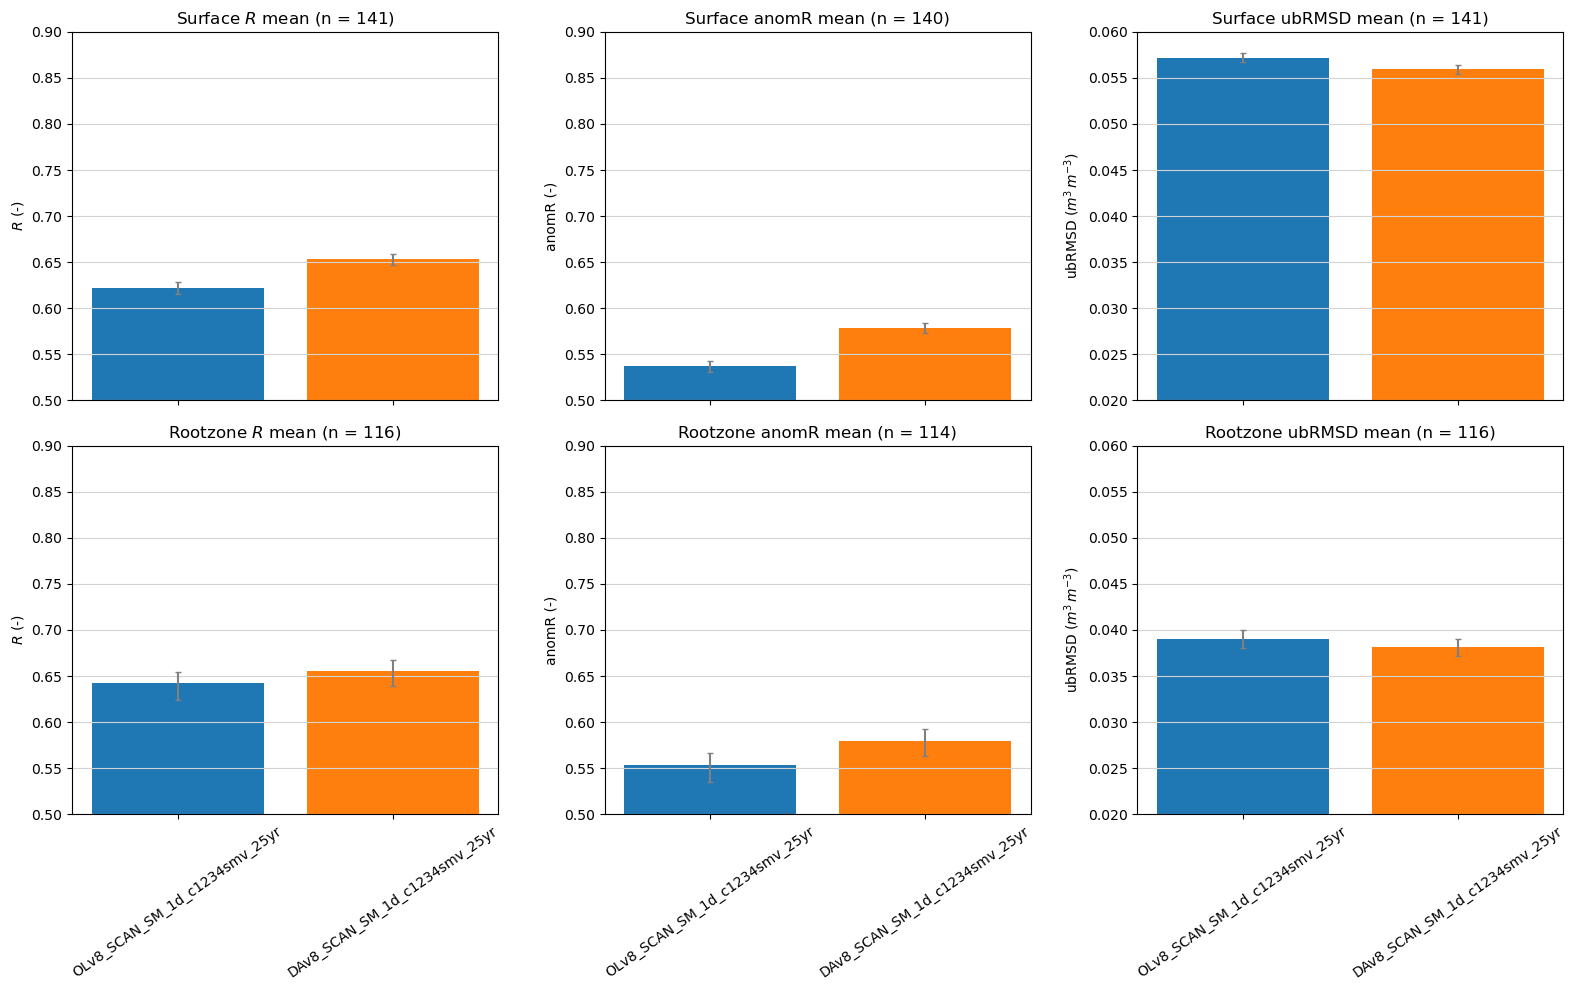

In [7]:
# ---- bar plots (surface vs root-zone) ----

num_expts = len(exp_keys)
ind = np.arange(num_expts)

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

axs[0, 0].bar(ind, R_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 0].errorbar(ind, R_mean[0, :num_expts], yerr=R_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[0, 0].set_ylabel(r'$R$ (-)')
axs[0, 0].set_ylim(0.5, 0.9)
axs[0, 0].grid(axis='y', color='lightgrey')
axs[0, 0].set_title(f'Surface $R$ mean (n = {int(num_sites_r[0, 0])})')
axs[0, 0].set_xticks(ind)
axs[0, 0].set_xticklabels('', fontsize=1)

if anomR is not None:
    axs[0, 1].bar(ind, anomR_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
    axs[0, 1].errorbar(ind, anomR_mean[0, :num_expts], yerr=anomR_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
    axs[0, 1].set_ylabel('anomR (-)')
    axs[0, 1].set_ylim(0.5, 0.9)
    axs[0, 1].grid(axis='y', color='lightgrey')
    axs[0, 1].set_title(f'Surface anomR mean (n = {int(num_sites_anomr[0, 0])})')
    axs[0, 1].set_xticks(ind)
    axs[0, 1].set_xticklabels('', fontsize=1)

axs[0, 2].bar(ind, ubRMSE_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 2].errorbar(ind, ubRMSE_mean[0, :num_expts], yerr=ubRMSE_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[0, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)')
axs[0, 2].set_ylim(0.02, 0.06)
axs[0, 2].grid(axis='y', color='lightgrey')
axs[0, 2].set_title(f'Surface ubRMSD mean (n = {int(num_sites_ubrmse[0, 0])})')
axs[0, 2].set_xticks(ind)
axs[0, 2].set_xticklabels('', fontsize=1)

axs[1, 0].bar(ind, R_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 0].errorbar(ind, R_mean[1, :num_expts], yerr=R_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[1, 0].set_ylabel(r'$R$ (-)')
axs[1, 0].set_ylim(0.5, 0.9)
axs[1, 0].grid(axis='y', color='lightgrey')
axs[1, 0].set_title(f'Rootzone $R$ mean (n = {int(num_sites_r[1, 0])})')
axs[1, 0].set_xticks(ind)
axs[1, 0].set_xticklabels(exp_labels[:num_expts], rotation=35)

if anomR is not None:
    axs[1, 1].bar(ind, anomR_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
    axs[1, 1].errorbar(ind, anomR_mean[1, :num_expts], yerr=anomR_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
    axs[1, 1].set_ylabel('anomR (-)')
    axs[1, 1].set_ylim(0.5, 0.9)
    axs[1, 1].grid(axis='y', color='lightgrey')
    axs[1, 1].set_title(f'Rootzone anomR mean (n = {int(num_sites_anomr[1, 0])})')
    axs[1, 1].set_xticks(ind)
    axs[1, 1].set_xticklabels(exp_labels[:num_expts], rotation=35)

axs[1, 2].bar(ind, ubRMSE_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 2].errorbar(ind, ubRMSE_mean[1, :num_expts], yerr=ubRMSE_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[1, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)')
axs[1, 2].set_ylim(0.02, 0.06)
axs[1, 2].grid(axis='y', color='lightgrey')
axs[1, 2].set_title(f'Rootzone ubRMSD mean (n = {int(num_sites_ubrmse[1, 0])})')
axs[1, 2].set_xticks(ind)
axs[1, 2].set_xticklabels(exp_labels[:num_expts], rotation=35)

plt.tight_layout()
plt.show()


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/3133721335.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)


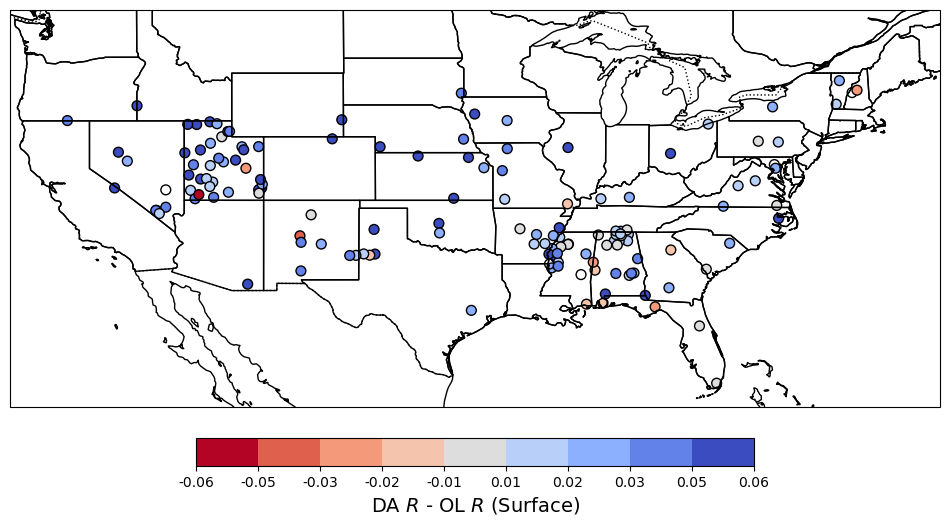

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/3133721335.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)


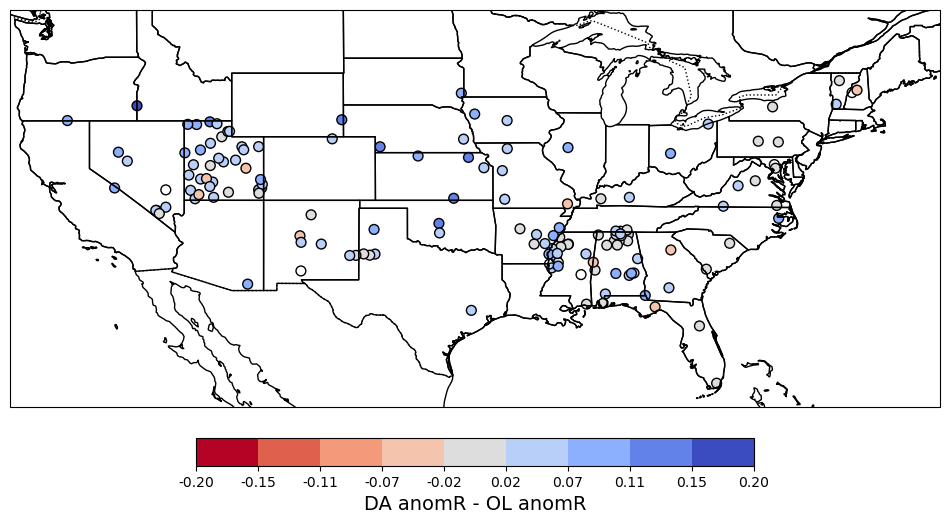

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/3133721335.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)


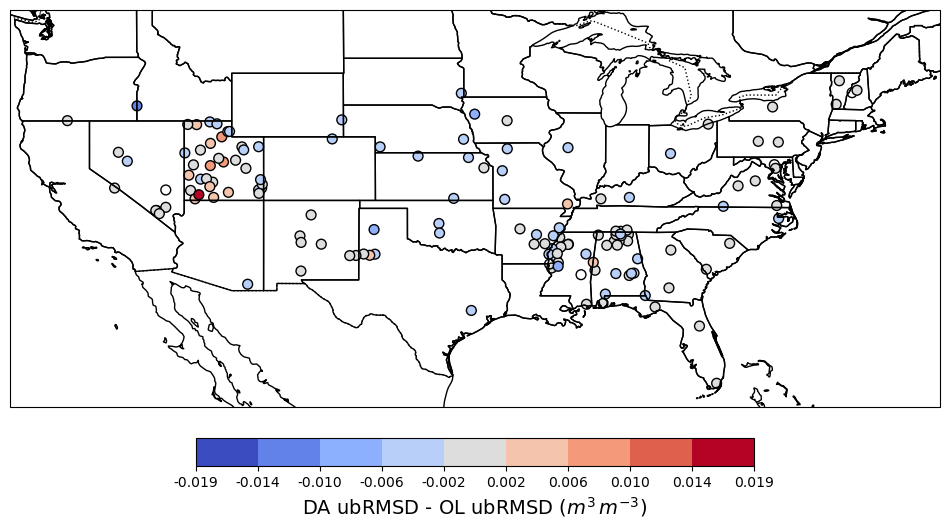

In [8]:
# ---- station maps: DA - OL (if 2 experiments and cartopy available) ----

if len(exp_keys) == 2 and meta and HAS_CARTOPY:
    lon = np.array(meta["lon"], dtype=float)
    lat = np.array(meta["lat"], dtype=float)

    # DA - OL for surface R
    R_diff = R[:, :, 1] - R[:, :, 0]
    levels = np.linspace(-0.06, 0.06, 10)
    cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)

    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

    sc = ax.scatter(lon, lat, c=R_diff[:, 0], cmap=cmap, s=50, edgecolor='k',
                    transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
    cbar.set_label(r'DA $R$ - OL $R$ (Surface)', fontsize=14)
    cbar.set_ticks(levels)
    cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    plt.show()

    if anomR is not None:
        anomR_diff = anomR[:, :, 1] - anomR[:, :, 0]
        surf_diff = anomR_diff[:, 0]
        maxabs = np.nanmax(np.abs(surf_diff))
        levels = np.linspace(-maxabs, maxabs, 10) if maxabs and np.isfinite(maxabs) else np.linspace(-0.01, 0.01, 10)
        cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)

        fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, edgecolor='black')
        ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

        sc = ax.scatter(lon, lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                        transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

        cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
        cbar.set_label('DA anomR - OL anomR', fontsize=14)
        cbar.set_ticks(levels)
        cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        plt.show()

    ubRMSE_diff = ubRMSE[:, :, 1] - ubRMSE[:, :, 0]
    surf_diff = ubRMSE_diff[:, 0]
    maxabs = np.nanmax(np.abs(surf_diff))
    levels = np.linspace(-maxabs, maxabs, 10) if maxabs and np.isfinite(maxabs) else np.linspace(-0.01, 0.01, 10)
    cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)

    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

    sc = ax.scatter(lon, lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                    transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
    cbar.set_label('DA ubRMSD - OL ubRMSD ($m^3\,m^{-3}$)', fontsize=14)
    cbar.set_ticks(levels)
    cbar.ax.set_xticklabels([f"{lvl:.3f}" for lvl in levels])
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    plt.show()
else:
    if not HAS_CARTOPY:
        print("Cartopy not available; skipping station maps.")
    elif len(exp_keys) != 2:
        print("Need exactly 2 experiments to plot DA - OL maps.")
    else:
        print("Station lat/lon not found in MAT file; skipping maps.")


## Date-range statistics (MATLAB range-aware block)

This section mirrors the `SMskill_vs_INSITU_single_LS_expt_date_ranges.m` range-aware stats. It
computes stats per time range using the cached raw time series.


In [9]:
# ---- range definitions (match MATLAB) ----
import numpy as np

ranges = [
    ("ALL", "2000-06-01", "2024-06-30"),
    ("pre-ASCAT", "2000-06-01", "2007-05-31"),
    ("pre-SMAP", "2007-06-01", "2015-03-31"),
    ("SMAP-era", "2015-04-01", "2024-06-30"),
]


In [10]:
# ---- build masks from date_time_vec ----
import datetime as _dt

# Reuse last loaded MAT (first in results) for time vector
if not results:
    raise RuntimeError("Run the raw_timeseries processing cell first.")

# We assume all experiments share the same date_time_vec in the raw file
first_key = list(results.keys())[0]
raw_path = None
for p in RAW_MAT_FILES:
    if first_key in p.name:
        raw_path = p
        break
if raw_path is None:
    raw_path = RAW_MAT_FILES[0]

mat_tmp = load_mat_file(raw_path)
if "date_time_vec" not in mat_tmp:
    raise KeyError("date_time_vec not found in raw MAT file")

dt_vec = mat_tmp["date_time_vec"]

year = mat_struct_to_array(dt_vec, "year").astype(int).ravel()
month = mat_struct_to_array(dt_vec, "month").astype(int).ravel()
day = mat_struct_to_array(dt_vec, "day").astype(int).ravel()
hour = mat_struct_to_array(dt_vec, "hour").astype(int).ravel()
minute = mat_struct_to_array(dt_vec, "min").astype(int).ravel() if hasattr(dt_vec, 'min') else np.zeros_like(hour)
second = mat_struct_to_array(dt_vec, "sec").astype(int).ravel() if hasattr(dt_vec, 'sec') else np.zeros_like(hour)

# build datetime vector
_tvec = np.array([
    _dt.datetime(int(y), int(m), int(d), int(h), int(mi), int(s))
    for y, m, d, h, mi, s in zip(year, month, day, hour, minute, second)
])

range_masks = []
for name, s0, s1 in ranges:
    t0 = _dt.datetime.fromisoformat(s0)
    t1 = _dt.datetime.fromisoformat(s1)
    range_masks.append((_tvec >= t0) & (_tvec <= t1))
range_masks = np.stack(range_masks, axis=1)  # [T, Kr]


In [11]:
# ---- compute stats by range for each experiment ----

range_stats = {}

# coverage filter settings (mirrors LS_insitu_plotter_102625.ipynb)
MIN_DAYS_PER_PERIOD_SURF = 1000
MIN_DAYS_PER_PERIOD_RZ = 500

# baseline choice for sub-period stats: "range" or "full"
BASELINE = "full"
# optional site exclusions by index
EXCLUDE_SITE_IDS = [ ]  # e.g., [12, 45, 78]

for exp_key, payload in results.items():
    # reload the raw arrays for this experiment
    raw_path = None
    for p in RAW_MAT_FILES:
        if exp_key in p.name:
            raw_path = p
            break
    if raw_path is None:
        raise RuntimeError(f"Could not match raw file for {exp_key}")
    mat = load_mat_file(raw_path)

    ldas_sm_org = mat["LDAS_sm_org"]
    insitu_sm = mat["INSITU_sm"]

    if ldas_sm_org.ndim == 4:
        ldas_sm_org = ldas_sm_org[:, :, :, 0]

    ldas_sm_full = ldas_sm_org[:, :2, :]
    insitu_full = insitu_sm

    doy_vec = mat_struct_to_array(mat["date_time_vec"], "dofyr").astype(int).ravel()

    # build date vector for coverage counts
    year = mat_struct_to_array(mat["date_time_vec"], "year").astype(int).ravel()
    month = mat_struct_to_array(mat["date_time_vec"], "month").astype(int).ravel()
    day = mat_struct_to_array(mat["date_time_vec"], "day").astype(int).ravel()
    import datetime as _dt
    dates_only = np.array([_dt.date(int(y), int(m), int(d)) for y, m, d in zip(year, month, day)])

    Nmin = 200 if "daily" in FILE_TAG else 480
    Nmin_day = 60  # fixed for this workflow

    Kr = range_masks.shape[1]
    n_site = ldas_sm_full.shape[2]
    n_depth = ldas_sm_full.shape[1]

    # allocate: [site, depth, range]
    R = np.full((n_site, n_depth, Kr), np.nan)
    RLO = np.full((n_site, n_depth, Kr), np.nan)
    RUP = np.full((n_site, n_depth, Kr), np.nan)
    ubRMSE = np.full((n_site, n_depth, Kr), np.nan)
    ubRMSELO = np.full((n_site, n_depth, Kr), np.nan)
    ubRMSEUP = np.full((n_site, n_depth, Kr), np.nan)
    anomR = np.full((n_site, n_depth, Kr), np.nan) if ADD_ANOMR else None
    anomRLO = np.full((n_site, n_depth, Kr), np.nan) if ADD_ANOMR else None
    anomRUP = np.full((n_site, n_depth, Kr), np.nan) if ADD_ANOMR else None

    # coverage filter: require at least MIN_DAYS_PER_PERIOD in EACH range per site/depth
    eligible = np.zeros((n_depth, n_site), dtype=bool)
    for d in range(n_depth):
        min_days = MIN_DAYS_PER_PERIOD_SURF if d == 0 else MIN_DAYS_PER_PERIOD_RZ
        for j in range(n_site):
            if j in EXCLUDE_SITE_IDS:
                continue
            valid = ~np.isnan(insitu_full[:, d, j])
            if not np.any(valid):
                continue
            days = np.unique(dates_only[valid])
            counts = []
            for r_idx, (name, s0, s1) in enumerate(ranges):
                t0 = _dt.datetime.fromisoformat(s0).date()
                t1 = _dt.datetime.fromisoformat(s1).date()
                if r_idx < len(ranges) - 1:
                    c = np.count_nonzero((days >= t0) & (days < t1))
                else:
                    c = np.count_nonzero((days >= t0) & (days <= t1))
                counts.append(c)
            if all(c >= min_days for c in counts):
                eligible[d, j] = True

    # precompute full-period baseline if requested
    bias_full = None
    obs_anom_full = None
    mod_anom_full = None
    if BASELINE == "full":

        if BASELINE == "full" and obs_anom_full is not None:
            # quick diagnostic on a single site/depth
            for d_test in range(min(1, n_depth)):
                for s_test in range(min(1, n_site)):
                    obs_full = obs_anom_full[:, d_test, s_test]
                    mod_full = mod_anom_full[:, d_test, s_test]
                    print(f"Full-baseline anom sample (depth {d_test}, site {s_test}):", np.nanmean(obs_full), np.nanmean(mod_full))
                    break
                break

        bias_full = np.full((n_depth, n_site), np.nan)
        if ADD_ANOMR:
            obs_anom_full = np.full(ldas_sm_full.shape, np.nan)
            mod_anom_full = np.full(ldas_sm_full.shape, np.nan)
        for j_depth in range(n_depth):
            for i_site in range(n_site):
                obs = insitu_full[:, j_depth, i_site].astype(float)
                mod = ldas_sm_full[:, j_depth, i_site].astype(float)
                obs[np.isnan(mod)] = np.nan
                mod[np.isnan(obs)] = np.nan
                if np.all(np.isnan(obs)):
                    continue
                bias_full[j_depth, i_site] = np.nanmean(obs - mod)
                if ADD_ANOMR:
                    obs_anom_full[:, j_depth, i_site] = compute_anom(obs, doy_vec, Nmin_day=Nmin_day)
                    mod_anom_full[:, j_depth, i_site] = compute_anom(mod, doy_vec, Nmin_day=Nmin_day)

    for k in range(Kr):
        mask = range_masks[:, k]
        if np.sum(mask) == 0:
            continue
        ldas_sm = ldas_sm_full[mask, :, :].copy()
        insitu_rng = insitu_full[mask, :, :].copy()

        ldas_sm[ldas_sm == 0] = np.nan
        ldas_sm[np.isnan(insitu_rng)] = np.nan
        insitu_rng[np.isnan(ldas_sm)] = np.nan

        for i_site in range(n_site):
            for j_depth in range(n_depth):
                if not eligible[j_depth, i_site]:
                    continue
                tmp = np.column_stack([insitu_rng[:, j_depth, i_site], ldas_sm[:, j_depth, i_site]])
                s = get_validation_stats(tmp, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
                R[i_site, j_depth, k] = s["R"]
                RLO[i_site, j_depth, k] = s["RLO"]
                RUP[i_site, j_depth, k] = s["RUP"]

                mse = s["MSE"]
                ci_mse = s["CI_MSE"]
                if BASELINE == "full" and bias_full is not None:
                    bf = bias_full[j_depth, i_site]
                    ubmse = mse - bf**2 if not np.isnan(mse) and not np.isnan(bf) else np.nan
                    ubRMSE[i_site, j_depth, k] = np.sqrt(ubmse) if ubmse is not None and ubmse >= 0 else np.nan
                    if not np.isnan(ci_mse) and not np.isnan(mse) and not np.isnan(bf):
                        ubRMSELO[i_site, j_depth, k] = np.sqrt(max(ci_mse + mse - bf**2, 0)) - ubRMSE[i_site, j_depth, k]
                        ubRMSEUP[i_site, j_depth, k] = np.sqrt(max(ci_mse + mse - bf**2, 0)) - ubRMSE[i_site, j_depth, k]
                else:
                    ubmse = s["ubMSE"]
                    ubRMSE[i_site, j_depth, k] = np.sqrt(ubmse) if not np.isnan(ubmse) else np.nan
                    if not np.isnan(s["ubMSELO"]):
                        ubRMSELO[i_site, j_depth, k] = np.sqrt(max(ubmse + s["ubMSEUP"], 0)) - ubRMSE[i_site, j_depth, k]
                        ubRMSEUP[i_site, j_depth, k] = np.sqrt(max(ubmse + s["ubMSEUP"], 0)) - ubRMSE[i_site, j_depth, k]

                if ADD_ANOMR:
                    if BASELINE == "full" and obs_anom_full is not None and mod_anom_full is not None:
                        obs_anom = obs_anom_full[mask, j_depth, i_site]
                        mod_anom = mod_anom_full[mask, j_depth, i_site]
                    else:
                        doy_rng = doy_vec[mask]
                        obs = insitu_rng[:, j_depth, i_site]
                        mod = ldas_sm[:, j_depth, i_site]
                        obs[np.isnan(mod)] = np.nan
                        mod[np.isnan(obs)] = np.nan
                        obs_anom = compute_anom(obs, doy_rng, Nmin_day=Nmin_day)
                        mod_anom = compute_anom(mod, doy_rng, Nmin_day=Nmin_day)
                    tmp_anom = np.column_stack([obs_anom, mod_anom])
                    sa = get_validation_stats(tmp_anom, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
                    anomR[i_site, j_depth, k] = sa["R"]
                    anomRLO[i_site, j_depth, k] = sa["RLO"]
                    anomRUP[i_site, j_depth, k] = sa["RUP"]

    range_stats[exp_key] = dict(
        R=R, RLO=RLO, RUP=RUP,
        ubRMSE=ubRMSE, ubRMSELO=ubRMSELO, ubRMSEUP=ubRMSEUP,
        anomR=anomR, anomRLO=anomRLO, anomRUP=anomRUP,
        ranges=[r[0] for r in ranges],
        eligible=eligible,
        baseline=BASELINE,
    )

print("Range stats computed for:", list(range_stats.keys()))
print(f"Baseline mode: {BASELINE}")


Range stats computed for: ['LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr', 'LS_DAv8_M36_SCAN_SM_1d_c1234smv_25yr']
Baseline mode: full


In [12]:
# ---- save eligible site list with lat/lon ----
import numpy as np
import pandas as pd
from pathlib import Path

DEPTH = 0  # 0=surface, 1=rootzone

def _pick_coord(mat, n_site, keys):
    for k in keys:
        if k in mat:
            arr = np.array(mat[k]).squeeze()
            if arr.size == n_site:
                return arr.astype(float)
            # handle common 2D shapes (n_site, 1) or (1, n_site) or repeated columns
            if arr.ndim >= 2 and n_site in arr.shape:
                if arr.shape[0] == n_site:
                    return np.array(arr[:, 0]).astype(float)
                if arr.shape[1] == n_site:
                    return np.array(arr[0, :]).astype(float)
            # handle repeated stacks where size is multiple of n_site
            if arr.size % n_site == 0 and arr.size > 0:
                reshaped = arr.reshape(n_site, -1)
                return np.array(reshaped[:, 0]).astype(float)
    return None

# intersect eligible sites across experiments
exp_keys = list(range_stats.keys())
if not exp_keys:
    raise RuntimeError("range_stats is empty")

eligible = None
for k in exp_keys:
    e = range_stats[k].get("eligible")
    if e is None:
        continue
    eligible = e if eligible is None else (eligible & e)
if eligible is None:
    raise RuntimeError("eligible mask not found in range_stats")

site_idx = np.where(eligible[DEPTH])[0]

# load one raw mat to get site coordinates
mat = load_mat_file(RAW_MAT_FILES[0])
# preferred key names
lat_keys = ["site_lat", "INSITU_lat", "station_lat", "lat", "LAT", "lats"]
lon_keys = ["site_lon", "INSITU_lon", "station_lon", "lon", "LON", "lons"]

n_site = eligible.shape[1]
lat = _pick_coord(mat, n_site, lat_keys)
lon = _pick_coord(mat, n_site, lon_keys)

if lat is None or lon is None:
    # fallback: any key containing 'lat'/'lon' with correct length
    lat_candidates = []
    lon_candidates = []
    for k, v in mat.items():
        if k.startswith("__"):
            continue
        arr = np.array(v).squeeze()
        if arr.size != n_site:
            continue
        kl = k.lower()
        if "lat" in kl:
            lat_candidates.append(k)
        if "lon" in kl:
            lon_candidates.append(k)
    raise RuntimeError(
        "Could not find lat/lon arrays with length n_site. "
        f"Lat candidates: {lat_candidates}; Lon candidates: {lon_candidates}"
    )

df = pd.DataFrame({
    "site_idx": site_idx.astype(int),
    "lat": lat[site_idx],
    "lon": lon[site_idx],
    "depth": "rootzone" if DEPTH == 1 else "surface",
})

out_csv = Path("projects/M21C_ls/notebooks") / f"eligible_sites_{df['depth'].iloc[0]}.csv"
df.to_csv(out_csv, index=False)
print(f"Saved eligible sites: {out_csv} (n={len(df)})")


Saved eligible sites: projects/M21C_ls/notebooks/eligible_sites_surface.csv (n=19)


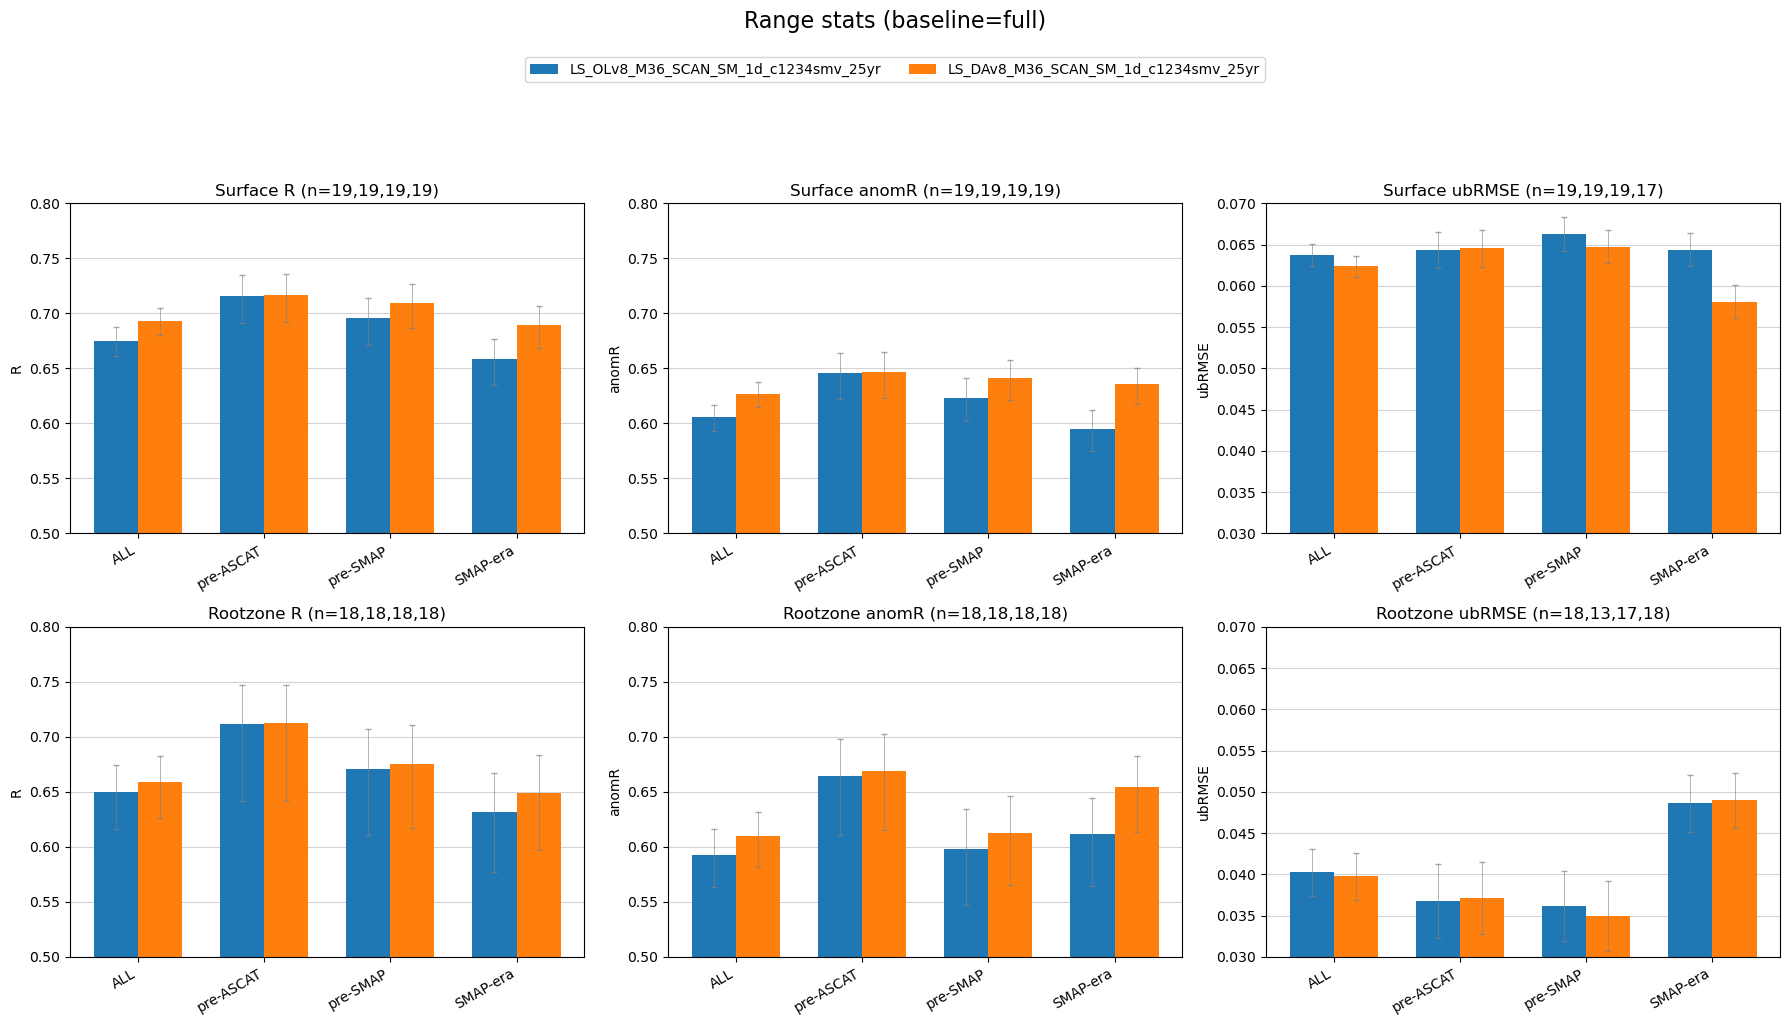

In [13]:
# ---- bar plots by time range ----
import numpy as np
import matplotlib.pyplot as plt

if not range_stats:
    raise RuntimeError("No range_stats found. Run the range stats cell first.")

exp_keys = list(range_stats.keys())
range_names = range_stats[exp_keys[0]]["ranges"]

R = np.stack([range_stats[k]["R"] for k in exp_keys], axis=3)          # [site, depth, range, exp]
RLO = np.stack([range_stats[k]["RLO"] for k in exp_keys], axis=3)
RUP = np.stack([range_stats[k]["RUP"] for k in exp_keys], axis=3)

ub = np.stack([range_stats[k]["ubRMSE"] for k in exp_keys], axis=3)
ubLO = np.stack([range_stats[k]["ubRMSELO"] for k in exp_keys], axis=3)
ubUP = np.stack([range_stats[k]["ubRMSEUP"] for k in exp_keys], axis=3)

anom = None
anomLO = None
anomUP = None
if range_stats[exp_keys[0]].get("anomR") is not None:
    anom = np.stack([range_stats[k]["anomR"] for k in exp_keys], axis=3)
    anomLO = np.stack([range_stats[k]["anomRLO"] for k in exp_keys], axis=3)
    anomUP = np.stack([range_stats[k]["anomRUP"] for k in exp_keys], axis=3)

n_ranges = len(range_names)
ind = np.arange(n_ranges)
width = 0.35
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# use thin, subtle error bars
err_kw = dict(ecolor='grey', elinewidth=0.6, capsize=2, alpha=0.7)

# helper: list n per range (min across experiments)

def n_list(arr, depth):
    valid = ~np.isnan(arr[:, depth, :, :])  # [site, range, exp]
    counts = np.sum(valid, axis=0)          # [range, exp]
    counts_min = np.nanmin(counts, axis=1)  # min across exp per range
    return [int(x) for x in counts_min]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Range stats (baseline={BASELINE})", fontsize=16, y=1.02)

# Surface R
for i, exp in enumerate(exp_keys):
    means = np.nanmean(R[:, 0, :, i], axis=0)
    num_sites = np.sum(~np.isnan(R[:, 0, :, i]), axis=0)
    ci_lo = np.nanmean(RLO[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    ci_up = np.nanmean(RUP[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
    axs[0, 0].bar(ind + i*width, means, width=width, yerr=yerr,
                 label=exp, color=colors[i % len(colors)], error_kw=err_kw)
axs[0, 0].set_title(f"Surface R (n={','.join(map(str, n_list(R, 0)))})")
axs[0, 0].set_xticks(ind + width*(len(exp_keys)-1)/2)
axs[0, 0].set_xticklabels(range_names, rotation=30, ha='right')
axs[0, 0].set_ylabel('R')
axs[0, 0].set_ylim(0.5, 0.8)
axs[0, 0].grid(axis='y', color='lightgrey')
axs[0, 0].set_axisbelow(True)

# Surface anomR
if anom is not None:
    for i, exp in enumerate(exp_keys):
        means = np.nanmean(anom[:, 0, :, i], axis=0)
        num_sites = np.sum(~np.isnan(anom[:, 0, :, i]), axis=0)
        ci_lo = np.nanmean(anomLO[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
        ci_up = np.nanmean(anomUP[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
        yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
        axs[0, 1].bar(ind + i*width, means, width=width, yerr=yerr,
                     label=exp, color=colors[i % len(colors)], error_kw=err_kw)
    axs[0, 1].set_title(f"Surface anomR (n={','.join(map(str, n_list(anom, 0)))})")
    axs[0, 1].set_xticks(ind + width*(len(exp_keys)-1)/2)
    axs[0, 1].set_xticklabels(range_names, rotation=30, ha='right')
    axs[0, 1].set_ylabel('anomR')
    axs[0, 1].set_ylim(0.5, 0.8)
    axs[0, 1].grid(axis='y', color='lightgrey')
    axs[0, 1].set_axisbelow(True)
else:
    axs[0, 1].axis('off')

# Surface ubRMSE
for i, exp in enumerate(exp_keys):
    means = np.nanmean(ub[:, 0, :, i], axis=0)
    num_sites = np.sum(~np.isnan(ub[:, 0, :, i]), axis=0)
    ci_lo = np.nanmean(ubLO[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    ci_up = np.nanmean(ubUP[:, 0, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
    axs[0, 2].bar(ind + i*width, means, width=width, yerr=yerr,
                 label=exp, color=colors[i % len(colors)], error_kw=err_kw)
axs[0, 2].set_title(f"Surface ubRMSE (n={','.join(map(str, n_list(ub, 0)))})")
axs[0, 2].set_xticks(ind + width*(len(exp_keys)-1)/2)
axs[0, 2].set_xticklabels(range_names, rotation=30, ha='right')
axs[0, 2].set_ylabel('ubRMSE')
axs[0, 2].set_ylim(0.03, 0.07)
axs[0, 2].grid(axis='y', color='lightgrey')
axs[0, 2].set_axisbelow(True)

# Rootzone R
for i, exp in enumerate(exp_keys):
    means = np.nanmean(R[:, 1, :, i], axis=0)
    num_sites = np.sum(~np.isnan(R[:, 1, :, i]), axis=0)
    ci_lo = np.nanmean(RLO[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    ci_up = np.nanmean(RUP[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
    axs[1, 0].bar(ind + i*width, means, width=width, yerr=yerr,
                 label=exp, color=colors[i % len(colors)], error_kw=err_kw)
axs[1, 0].set_title(f"Rootzone R (n={','.join(map(str, n_list(R, 1)))})")
axs[1, 0].set_xticks(ind + width*(len(exp_keys)-1)/2)
axs[1, 0].set_xticklabels(range_names, rotation=30, ha='right')
axs[1, 0].set_ylabel('R')
axs[1, 0].set_ylim(0.5, 0.8)
axs[1, 0].grid(axis='y', color='lightgrey')
axs[1, 0].set_axisbelow(True)

# Rootzone anomR
if anom is not None:
    for i, exp in enumerate(exp_keys):
        means = np.nanmean(anom[:, 1, :, i], axis=0)
        num_sites = np.sum(~np.isnan(anom[:, 1, :, i]), axis=0)
        ci_lo = np.nanmean(anomLO[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
        ci_up = np.nanmean(anomUP[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
        yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
        axs[1, 1].bar(ind + i*width, means, width=width, yerr=yerr,
                     label=exp, color=colors[i % len(colors)], error_kw=err_kw)
    axs[1, 1].set_title(f"Rootzone anomR (n={','.join(map(str, n_list(anom, 1)))})")
    axs[1, 1].set_xticks(ind + width*(len(exp_keys)-1)/2)
    axs[1, 1].set_xticklabels(range_names, rotation=30, ha='right')
    axs[1, 1].set_ylabel('anomR')
    axs[1, 1].set_ylim(0.5, 0.8)
    axs[1, 1].grid(axis='y', color='lightgrey')
    axs[1, 1].set_axisbelow(True)
else:
    axs[1, 1].axis('off')

# Rootzone ubRMSE
for i, exp in enumerate(exp_keys):
    means = np.nanmean(ub[:, 1, :, i], axis=0)
    num_sites = np.sum(~np.isnan(ub[:, 1, :, i]), axis=0)
    ci_lo = np.nanmean(ubLO[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    ci_up = np.nanmean(ubUP[:, 1, :, i], axis=0) / np.sqrt(np.maximum(num_sites, 1))
    yerr = np.array([np.abs(ci_lo), np.abs(ci_up)])
    axs[1, 2].bar(ind + i*width, means, width=width, yerr=yerr,
                 label=exp, color=colors[i % len(colors)], error_kw=err_kw)
axs[1, 2].set_title(f"Rootzone ubRMSE (n={','.join(map(str, n_list(ub, 1)))})")
axs[1, 2].set_xticks(ind + width*(len(exp_keys)-1)/2)
axs[1, 2].set_xticklabels(range_names, rotation=30, ha='right')
axs[1, 2].set_ylabel('ubRMSE')
axs[1, 2].set_ylim(0.03, 0.07)
axs[1, 2].grid(axis='y', color='lightgrey')
axs[1, 2].set_axisbelow(True)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(exp_keys), bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


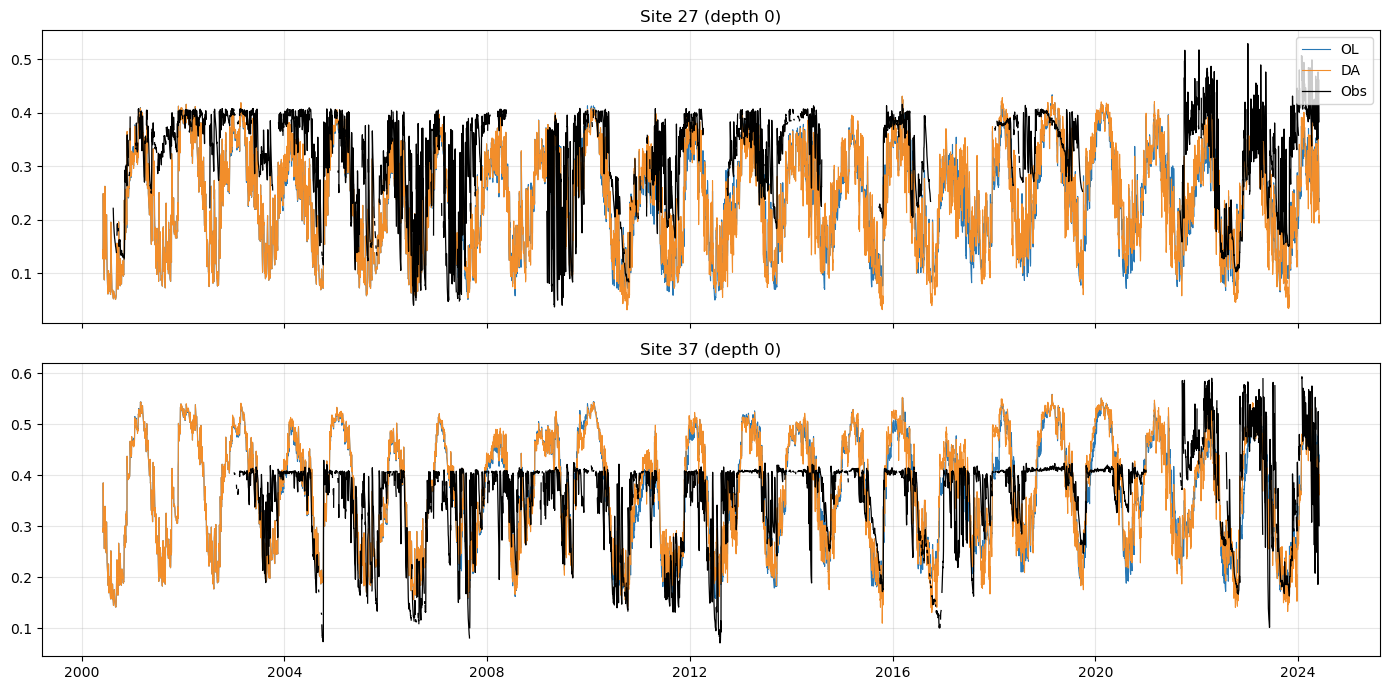

In [14]:
# ---- time series plots for selected sites (OL, DA, Obs) ----
import numpy as np
import matplotlib.pyplot as plt
import datetime as _dt

# config
DEPTH = 0  # 0=surface, 1=rootzone
MAX_SITES = 120

# pick sites from eligibility (intersection across experiments)
exp_keys = list(range_stats.keys())
if not exp_keys:
    raise RuntimeError("range_stats is empty")

eligible = None
for k in exp_keys:
    e = range_stats[k].get("eligible")
    if e is None:
        continue
    eligible = e if eligible is None else (eligible & e)
if eligible is None:
    raise RuntimeError("eligible mask not found in range_stats")

site_indices = np.where(eligible[DEPTH])[0][:MAX_SITES]
if site_indices.size == 0:
    raise RuntimeError("No eligible sites found for plotting")

site_indices = [27, 37]  # specify site indices manually if desired

# load raw series for each experiment
series = {}
obs = None
timestamps = None

for raw_path in RAW_MAT_FILES:
    mat = load_mat_file(raw_path)
    ldas_sm_org = mat["LDAS_sm_org"]
    insitu_sm = mat["INSITU_sm"]

    if ldas_sm_org.ndim == 4:
        ldas_sm_org = ldas_sm_org[:, :, :, 0]

    ldas_sm = ldas_sm_org[:, :2, :]
    insitu = insitu_sm

    # timestamps
    dtv = mat["date_time_vec"]
    year = mat_struct_to_array(dtv, "year").astype(int).ravel()
    month = mat_struct_to_array(dtv, "month").astype(int).ravel()
    day = mat_struct_to_array(dtv, "day").astype(int).ravel()
    hour = mat_struct_to_array(dtv, "hour").astype(int).ravel()
    minute = mat_struct_to_array(dtv, "min").astype(int).ravel() if hasattr(dtv, 'min') else np.zeros_like(hour)
    second = mat_struct_to_array(dtv, "sec").astype(int).ravel() if hasattr(dtv, 'sec') else np.zeros_like(hour)

    timestamps = np.array([
        _dt.datetime(int(y), int(m), int(d), int(h), int(mi), int(s))
        for y, m, d, h, mi, s in zip(year, month, day, hour, minute, second)
    ])

    exp_key = raw_path.name.replace("_raw_timeseries.mat", "")
    series[exp_key] = ldas_sm

    if obs is None:
        obs = insitu

# select OL/DA keys
ol_key = [k for k in series if "OL" in k][0]
da_key = [k for k in series if "DA" in k][0]

nrows = int(np.ceil(len(site_indices) / 1))
fig, axs = plt.subplots(len(site_indices), 1, figsize=(14, 3.5 * len(site_indices)), sharex=True)
if len(site_indices) == 1:
    axs = [axs]

for ax, idx in zip(axs, site_indices):
    ax.plot(timestamps, series[ol_key][:, DEPTH, idx], color='#2878B5', linewidth=0.8, label='OL')
    ax.plot(timestamps, series[da_key][:, DEPTH, idx], color='#F28E2B', linewidth=0.8, label='DA')
    ax.plot(timestamps, obs[:, DEPTH, idx], color='k', linewidth=0.9, label='Obs', zorder=3)
    ax.set_title(f"Site {idx} (depth {DEPTH})")
    ax.grid(True, alpha=0.3)

axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()


In [15]:
# ---- obs-only reliability checks (coverage, change-points, variance, distribution, seasonal cycle) ----
import numpy as np
import pandas as pd

# config
# note: QC uses full obs arrays (no eligibility filtering)
DEPTH = 0  # 0=surface, 1=rootzone
MIN_YEARS = 20
COVERAGE_DROP_FRAC = 0.5   # drop >50% vs median
VAR_DRIFT_FACTOR = 2.0     # >2x or <0.5x variance
KS_PVAL_THRESH = 0.01
SEASONAL_CORR_MIN = 0.7

COVERAGE_PERIODS = [
    ("P1", (2000, 1, 1), (2007, 12, 31)),
    ("P2", (2008, 1, 1), (2015, 12, 31)),
    ("P3", (2016, 1, 1), (2024, 12, 31)),
]
MIN_DAYS_PER_PERIOD = 500

# use obs + timestamps from the time-series cell
if obs is None or timestamps is None:
    raise RuntimeError("obs or timestamps not loaded; run time-series cell first")

n_times, n_depth, n_sites = obs.shape

# build year/month for aggregation
years = np.array([t.year for t in timestamps])
months = np.array([t.month for t in timestamps])

# precompute early/late masks
mid_year = 2012
early = years <= mid_year
late = years > mid_year

qc = []

for j in range(n_sites):
    series = obs[:, DEPTH, j].astype(float)
    if np.all(np.isnan(series)):
        continue

    # coverage by year
    df = pd.DataFrame({"year": years, "val": series})
    cov = df.groupby("year")["val"].apply(lambda s: np.isfinite(s).sum())
    if cov.size < MIN_YEARS:
        continue
    cov_med = np.median(cov)
    cov_min = np.min(cov)
    cov_drop = (cov_min < cov_med * (1 - COVERAGE_DROP_FRAC))

    # coverage by custom periods
    period_counts = []
    for name, (y0, m0, d0), (y1, m1, d1) in COVERAGE_PERIODS:
        t0 = _dt.date(y0, m0, d0)
        t1 = _dt.date(y1, m1, d1)
        m = (dates_only >= t0) & (dates_only <= t1)
        period_counts.append(int(np.isfinite(series[m]).sum()))
    coverage_period_fail = any(c < MIN_DAYS_PER_PERIOD for c in period_counts)

    # yearly means for step-change detection (simple max diff between early/late)
    mean_by_year = df.groupby("year")["val"].mean()
    mean_early = np.nanmean(mean_by_year[mean_by_year.index <= mid_year])
    mean_late = np.nanmean(mean_by_year[mean_by_year.index > mid_year])
    step_change = np.abs(mean_late - mean_early)

    # variance drift: compare early/late variance
    var_early = np.nanvar(series[early])
    var_late = np.nanvar(series[late])
    var_ratio = (var_late / var_early) if (var_early > 0 and np.isfinite(var_late)) else np.nan
    var_drift = (var_ratio > VAR_DRIFT_FACTOR) or (var_ratio < 1.0 / VAR_DRIFT_FACTOR)

    # distribution shift: KS test early vs late
    try:
        from scipy.stats import ks_2samp
        v1 = series[early & np.isfinite(series)]
        v2 = series[late & np.isfinite(series)]
        if v1.size > 10 and v2.size > 10:
            ks_p = ks_2samp(v1, v2).pvalue
        else:
            ks_p = np.nan
    except Exception:
        ks_p = np.nan
    dist_shift = (np.isfinite(ks_p) and ks_p < KS_PVAL_THRESH)

    # seasonal cycle consistency: compare monthly climatology early vs late
    clim_early = pd.DataFrame({"m": months[early], "v": series[early]}).groupby("m")["v"].mean()
    clim_late = pd.DataFrame({"m": months[late], "v": series[late]}).groupby("m")["v"].mean()
    common_m = clim_early.index.intersection(clim_late.index)
    if common_m.size >= 6:
        c1 = clim_early.loc[common_m].to_numpy()
        c2 = clim_late.loc[common_m].to_numpy()
        if np.all(np.isfinite(c1)) and np.all(np.isfinite(c2)):
            seasonal_corr = np.corrcoef(c1, c2)[0, 1]
        else:
            seasonal_corr = np.nan
    else:
        seasonal_corr = np.nan
    seasonal_shift = (np.isfinite(seasonal_corr) and seasonal_corr < SEASONAL_CORR_MIN)

    qc.append({
        "site": j,
        "coverage_min": int(cov_min),
        "coverage_med": float(cov_med),
        "coverage_drop": bool(cov_drop),
        "period_counts": period_counts,
        "coverage_period_fail": bool(coverage_period_fail),
        "step_change_mean": float(step_change),
        "var_ratio": float(var_ratio) if np.isfinite(var_ratio) else np.nan,
        "var_drift": bool(var_drift),
        "ks_p": float(ks_p) if np.isfinite(ks_p) else np.nan,
        "dist_shift": bool(dist_shift),
        "seasonal_corr": float(seasonal_corr) if np.isfinite(seasonal_corr) else np.nan,
        "seasonal_shift": bool(seasonal_shift),
    })

qc_df = pd.DataFrame(qc)

# simple flag: any major issue
qc_df["flagged"] = qc_df[["coverage_drop", "var_drift", "dist_shift", "seasonal_shift"]].any(axis=1)

print("Flagged sites:", qc_df["flagged"].sum(), "of", len(qc_df))
qc_df.sort_values(["flagged", "coverage_min"], ascending=[False, True]).head(20)

# rank by consistency (lower score = better)
qc_df['score'] = (
    qc_df['coverage_drop'].astype(int)
    + 5 * qc_df['coverage_period_fail'].astype(int)
    + qc_df['var_drift'].astype(int)
    + qc_df['dist_shift'].astype(int)
    + qc_df['seasonal_shift'].astype(int)
)
qc_df['coverage_drop'].astype(int)
qc_df_sorted = qc_df.sort_values(['score', 'coverage_min'], ascending=[True, False])
qc_df_sorted.head(40)

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/1624544293.py:63: RuntimeWarning: Mean of empty slice
  mean_early = np.nanmean(mean_by_year[mean_by_year.index <= mid_year])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/1624544293.py:68: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_early = np.nanvar(series[early])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/1624544293.py:64: RuntimeWarning: Mean of empty slice
  mean_late = np.nanmean(mean_by_year[mean_by_year.index > mid_year])
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_8805/1624544293.py:69: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_late = np.nanvar(series[late])


Flagged sites: 135 of 142


,site,coverage_min,coverage_med,coverage_drop,period_counts,coverage_period_fail,step_change_mean,var_ratio,var_drift,ks_p,dist_shift,seasonal_corr,seasonal_shift,flagged,score
10,12,105,266.0,True,"[2082, 2112, 1988]",False,0.006089,0.787623,False,1.287025e-09,True,0.828869,False,True,2
19,21,103,337.0,True,"[2189, 2685, 2563]",False,0.024688,1.055568,False,1.383621e-158,True,0.847925,False,True,2
30,32,93,276.0,True,"[1939, 2194, 2384]",False,0.021317,1.190943,False,1.382130e-43,True,0.956213,False,True,2
6,8,18,227.0,True,"[1676, 1787, 1746]",False,0.012570,1.265328,False,1.065737e-04,True,0.933821,False,True,2
1,1,0,193.0,True,"[681, 756, 2290]",False,0.007036,0.828831,False,8.877313e-12,True,0.836325,False,True,2
2,2,0,245.0,True,"[1603, 1789, 1086]",False,0.068805,0.565755,False,1.193744e-108,True,0.769132,False,True,2
7,9,0,175.0,True,"[1544, 857, 1783]",False,0.010247,0.997948,False,2.592130e-83,True,0.812307,False,True,2
8,10,0,199.0,True,"[762, 2295, 1434]",False,0.030548,1.156222,False,6.284787e-52,True,0.805930,False,True,2
14,16,0,306.0,True,"[2194, 1726, 2587]",False,0.007142,1.595767,False,1.184463e-19,True,0.915124,False,True,2
16,18,0,251.0,True,"[558, 2303, 1746]",False,0.040435,1.109809,False,9.772360e-80,True,0.922586,False,True,2


In [16]:
# ---- save range stats (Python format) ----

OUT_DIR.mkdir(parents=True, exist_ok=True)

for exp_key, rs in range_stats.items():
    out_name = f"{exp_key}_stats_by_range.npz"
    out_path = OUT_DIR / out_name
    payload = {
        "ranges": np.array(rs["ranges"], dtype=object),
        "range_masks": range_masks,
        "R": rs["R"],
        "RLO": rs["RLO"],
        "RUP": rs["RUP"],
        "ubRMSE": rs["ubRMSE"],
        "ubRMSELO": rs["ubRMSELO"],
        "ubRMSEUP": rs["ubRMSEUP"],
    }
    if rs.get("anomR") is not None:
        payload["anomR"] = rs["anomR"]
        payload["anomRLO"] = rs["anomRLO"]
        payload["anomRUP"] = rs["anomRUP"]

    np.savez_compressed(out_path, **payload)
    print(f"Wrote {out_path}")


Wrote /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_stats_by_range.npz
Wrote /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_DAv8_M36_SCAN_SM_1d_c1234smv_25yr_stats_by_range.npz
